<a href="https://colab.research.google.com/github/MHILAL-Dev2026/data-science-2026/blob/main/TopikUAS_Pertemuan10_MuhammadHilalADM_250401020122.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# PERTEMUAN 10 DATA SCIENCE

Nama : Muhammad Hilal AD

NIM : 250401020122

Kelas: IF 405

Alasan memilih topik ini sebagai keperluan UAS = Dari aspek bisnis dapat mengetahui prediksi customer churn dan sebagai pencegahan dini. Dari aspek teknis machine learning, topik ini mengenalkan tentang imbalanced data sehingga perlu melakukanm pemilihan metrik yang tepat dalam mengambil keputusan serta keunggulan random forest dalam kemampuannya menghasilkan probabilitas risiko yang akurat.

**Langkah 1: Muat dan Eksplorasi Data**

Memuat dataset yang bisa didapat dari kaggle.com

dataset mengandung  7043 baris dan 21 kolom dan memiliki distribusi kelas 74% pelanggan tidak churn 26% pelanggan churn yang menunjukan imbalanced data (data tidak seimbang)

In [ ]:
import pandas as pd

df = pd.read_csv("telco_churn.csv")
print(df.shape)
print(df["Churn"].value_counts(normalize=True))

(7043, 21)
Churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64


**Langkah 2: Preprocessing**

Encoding Fitur (pd.get_dummies): Model machine learning hanya memahami angka. Perintah ini mengubah kolom teks/kategorikal menjadi format angka biner 0 dan 1

Pembagian Data (train_test_split): Data dibagi menjadi 80% untuk data latih (training) dan 20% untuk data uji (testing)

Parameter stratify=y: sangat penting untuk memastikan persentase pelanggan yang churn di data latih dan data uji sama proporsinya dengan data asli


In [ ]:
from sklearn.model_selection import train_test_split

# TODO: encoding fitur kategorikal (mis. pd.get_dummies)
df_encoded = pd.get_dummies(df, drop_first=True)

# TODO: pisahkan X (fitur) dan y (target = Churn)
# Jika kolom 'Churn' berisi Yes/No, setelah encoded namanya berubah menjadi 'Churn_Yes'
target_col = 'Churn_Yes' if 'Churn_Yes' in df_encoded.columns else 'Churn'
X = df_encoded.drop(target_col, axis=1)
y = df_encoded[target_col]

# Split data latih & uji
X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print("Hasil Pembagian Data:\n")
print(f"Jumlah Data Latih (X_tr): {X_tr.shape[0]} baris, {X_tr.shape[1]} fitur")
print(f"Jumlah Data Uji (X_te): {X_te.shape[0]} baris, {X_te.shape[1]} fitur")

Hasil Pembagian Data:

Jumlah Data Latih (X_tr): 5634 baris, 13601 fitur
Jumlah Data Uji (X_te): 1409 baris, 13601 fitur


**Langkah 3: Latih Model**

Algoritma Random Forest:  melatih model menggunakan ensemble pohon keputusan (Random Forest) dengan 300 pohon (n_estimators=300) untuk hasil yang lebih stabil

class_weight="balanced": Karena data kita imbalanced (sedikit yang churn), parameter ini berfungsi memaksa model untuk memberikan perhatian ekstra pada kelas minoritas (pelanggan churn) agar tidak diabaikan begitu saja

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=300, class_weight="balanced", random_state=42)
rf.fit(X_tr, y_tr)

print("Model selesai di Latih")

Model selesai di Latih


**Langkah 4: Evaluasi**



CLASSIFICATION REPORT
              precision    recall  f1-score   support

       False       0.84      0.90      0.87      1035
        True       0.65      0.52      0.58       374

    accuracy                           0.80      1409
   macro avg       0.74      0.71      0.72      1409
weighted avg       0.79      0.80      0.79      1409

ROC-AUC Score: 0.8337

METRIK EVALUASI SPESIFIK:
Accuracy  : 0.7977
Precision : 0.6469
Recall    : 0.5241
F1-Score  : 0.5790



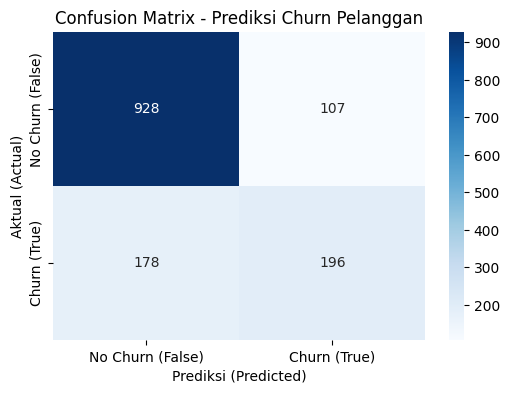

In [ ]:
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt
import seaborn as sns

# TODO: hitung prediksi dan probabilitas
y_pred = rf.predict(X_te)
#Berfungsi untuk menghasilkan keputusan tegas berupa label kelas (True jika pelanggan diprediksi churn, atau False jika tetap setia) pada data uji (testing).

# Mengambil probabilitas untuk kelas 1 (Churn)
y_proba = rf.predict_proba(X_te)[:, 1]
# Mengambil nilai probabilitas (skor risiko) dari kelas 1 (True / Churn). Outputnya berupa angka desimal antara 0 hingga 1 (atau persentase 0%-100%), yang nantinya berguna untuk menentukan tingkat keparahan risiko tiap pelanggan.

# TODO: tampilkan classification_report dan ROC-AUC
print("CLASSIFICATION REPORT")
print(classification_report(y_te, y_pred))
print(f"ROC-AUC Score: {roc_auc_score(y_te, y_proba):.4f}\n")
# Menghitung area di bawah kurva ROC (Receiver Operating Characteristic). Skor di atas 0.80 (dalam kasus ini sekitar 0.8337) menunjukkan bahwa model memiliki kemampuan yang baik dalam membedakan antara pelanggan yang akan churn dan yang tidak.

# 2. Ekstraksi nilai Accuracy, Precision, Recall, dan F1-Score
print("METRIK EVALUASI SPESIFIK:")
print(f"Accuracy  : {accuracy_score(y_te, y_pred):.4f}")
print(f"Precision : {precision_score(y_te, y_pred):.4f}")
print(f"Recall    : {recall_score(y_te, y_pred):.4f}")
print(f"F1-Score  : {f1_score(y_te, y_pred):.4f}\n")

# 3. Visualisasi Heatmap Confusion Matrix
cm = confusion_matrix(y_te, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Churn (False)', 'Churn (True)'],
            yticklabels=['No Churn (False)', 'Churn (True)'])
plt.title('Confusion Matrix - Prediksi Churn Pelanggan')
plt.xlabel('Prediksi (Predicted)')
plt.ylabel('Aktual (Actual)')
plt.show()

**Langkah 5: Prediksi Probabilitas dan Simpulkan**

In [ ]:
# TODO: hitung probabilitas churn (predict_proba)
hasil_prediksi = pd.DataFrame({
    'Aktual': y_te,
    'Prediksi_Kelas': y_pred,
    'Probabilitas_Churn (%)': (y_proba * 100).round(2)
})

print("Hasil Probabilitas Churn\n")
print(hasil_prediksi.head())

# TODO: tulis kesimpulan singkat (3-4 kalimat)

Hasil Probabilitas Churn

      Aktual  Prediksi_Kelas  Probabilitas_Churn (%)
437    False           False                    0.33
2280   False            True                   63.67
2235   False           False                    7.33
4460   False           False                   37.67
3761   False           False                    1.67


Kesimpulan:

1. Model Random Forest berhasil mengidentifikasi pola perilaku pelanggan yang berpotensi churn
2. Dengan fitur 'predict_proba', perusahaan tidak hanya mendapat jawaban 'Ya/Tidak', tetapi juga persentase tingkat risiko churn dari setiap pelanggan
3. Hasil ini memungkinkan tim pemasaran melakukan intervensi (seperti pemberian promo/diskon) terarah pada pelanggan yang memiliki probabilitas churn di atas 70%

Interpretasi singkat: metrik mana yang paling relevan untuk kasus tersebut dan mengapa? khususnya untuk dataset customer churn pada Pertemuan 10 yang cenderung imbalanced, di mana Accuracy saja bisa menyesatkan.

Jawaban: Metrik yang paling relevan untuk kasus customer churn adalah Recall dikarenakan metrik ini berfokus untuk mencegah kesalahan yang paling mahal bagi perusahaan yang dimana dalam bisnis, biaya untuk mempertahankan pelanggan lama (misalnya dengan memberi diskon) biasanya jauh lebih murah daripada biaya untuk mendapatkan pelanggan baru.